# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)


# **Data Loading**

In [2]:
import kagglehub
import os

# Download dataset dari Kaggle
dataset_path = kagglehub.dataset_download('shantanudhakadd/bank-customer-churn-prediction')
csv_path = os.path.join(dataset_path, 'Churn_Modelling.csv')

# Baca file CSV
data = pd.read_csv(csv_path)

# Tampilkan DataFrame untuk memastikan telah dibaca dengan benar
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Tampilkan informasi umum tentang dataset
print("\nInformasi dataset:")
data.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# Cek missing values
print("\nMissing values per fitur:")
print(data.isnull().sum())


Missing values per fitur:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [5]:
# Hapus kolom non-prediktif
data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Simpan salinan sebelum encoding untuk keperluan analisis
data_raw = data.copy()

data.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **EDA**

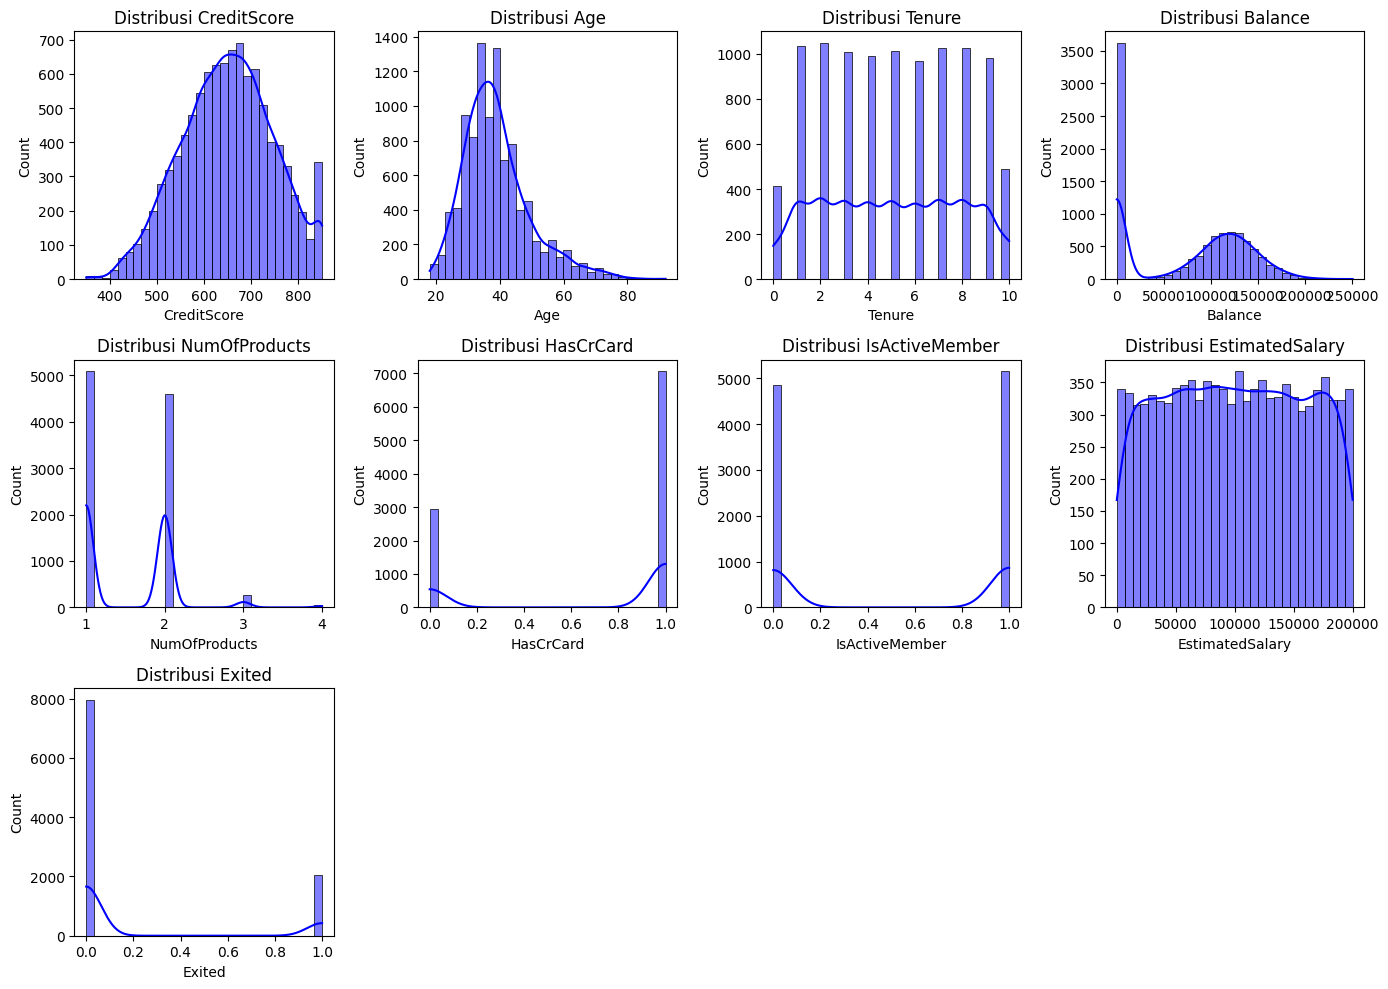

In [6]:
# Distribusi fitur numerik
num_features = data.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(data[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\3141806535.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data[column], palette='viridis')
C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\3141806535.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data[column], palette='viridis')


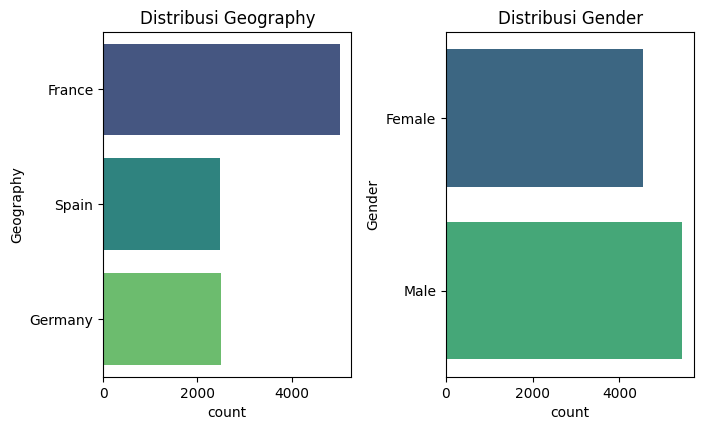

In [7]:
# Distribusi fitur kategorikal
cat_features = data.select_dtypes(include=[object])
plt.figure(figsize=(14, 8))
for i, column in enumerate(cat_features.columns, 1):
  plt.subplot(2, 4, i)
  sns.countplot(y=data[column], palette='viridis')
  plt.title(f"Distribusi {column}")
plt.tight_layout()
plt.show()

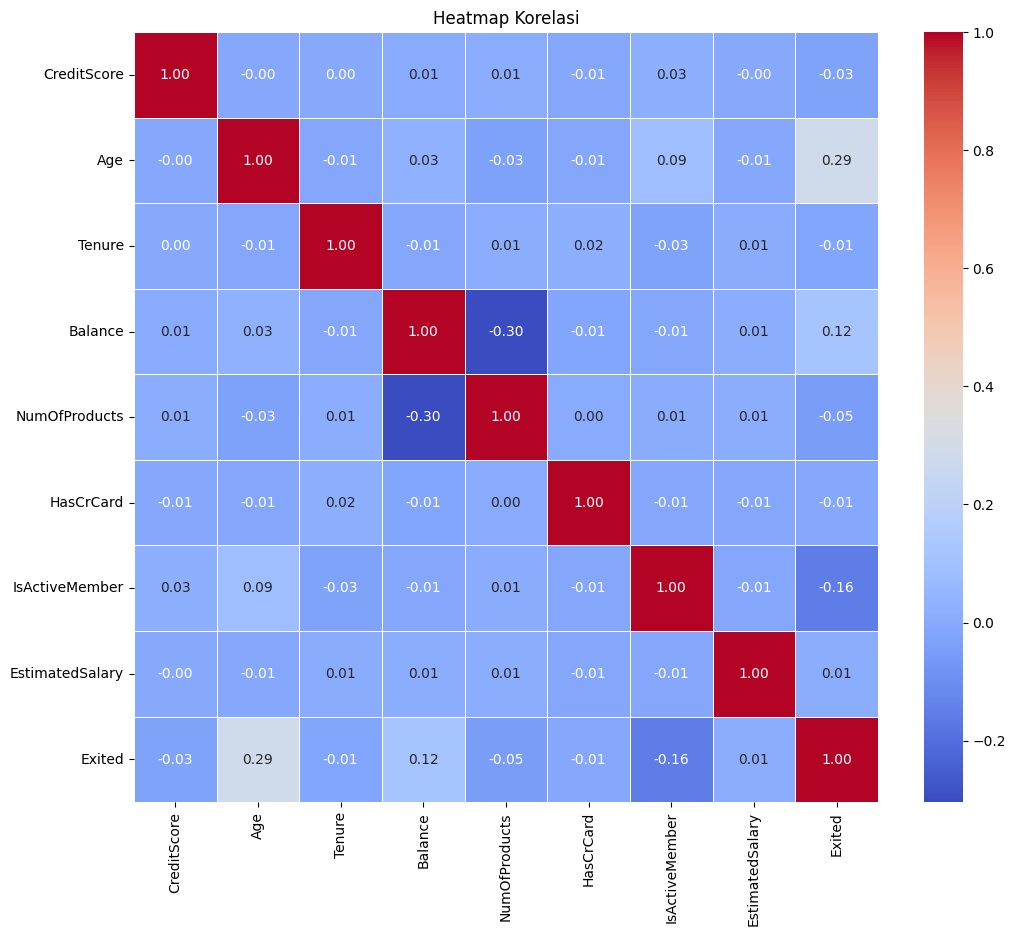

In [8]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

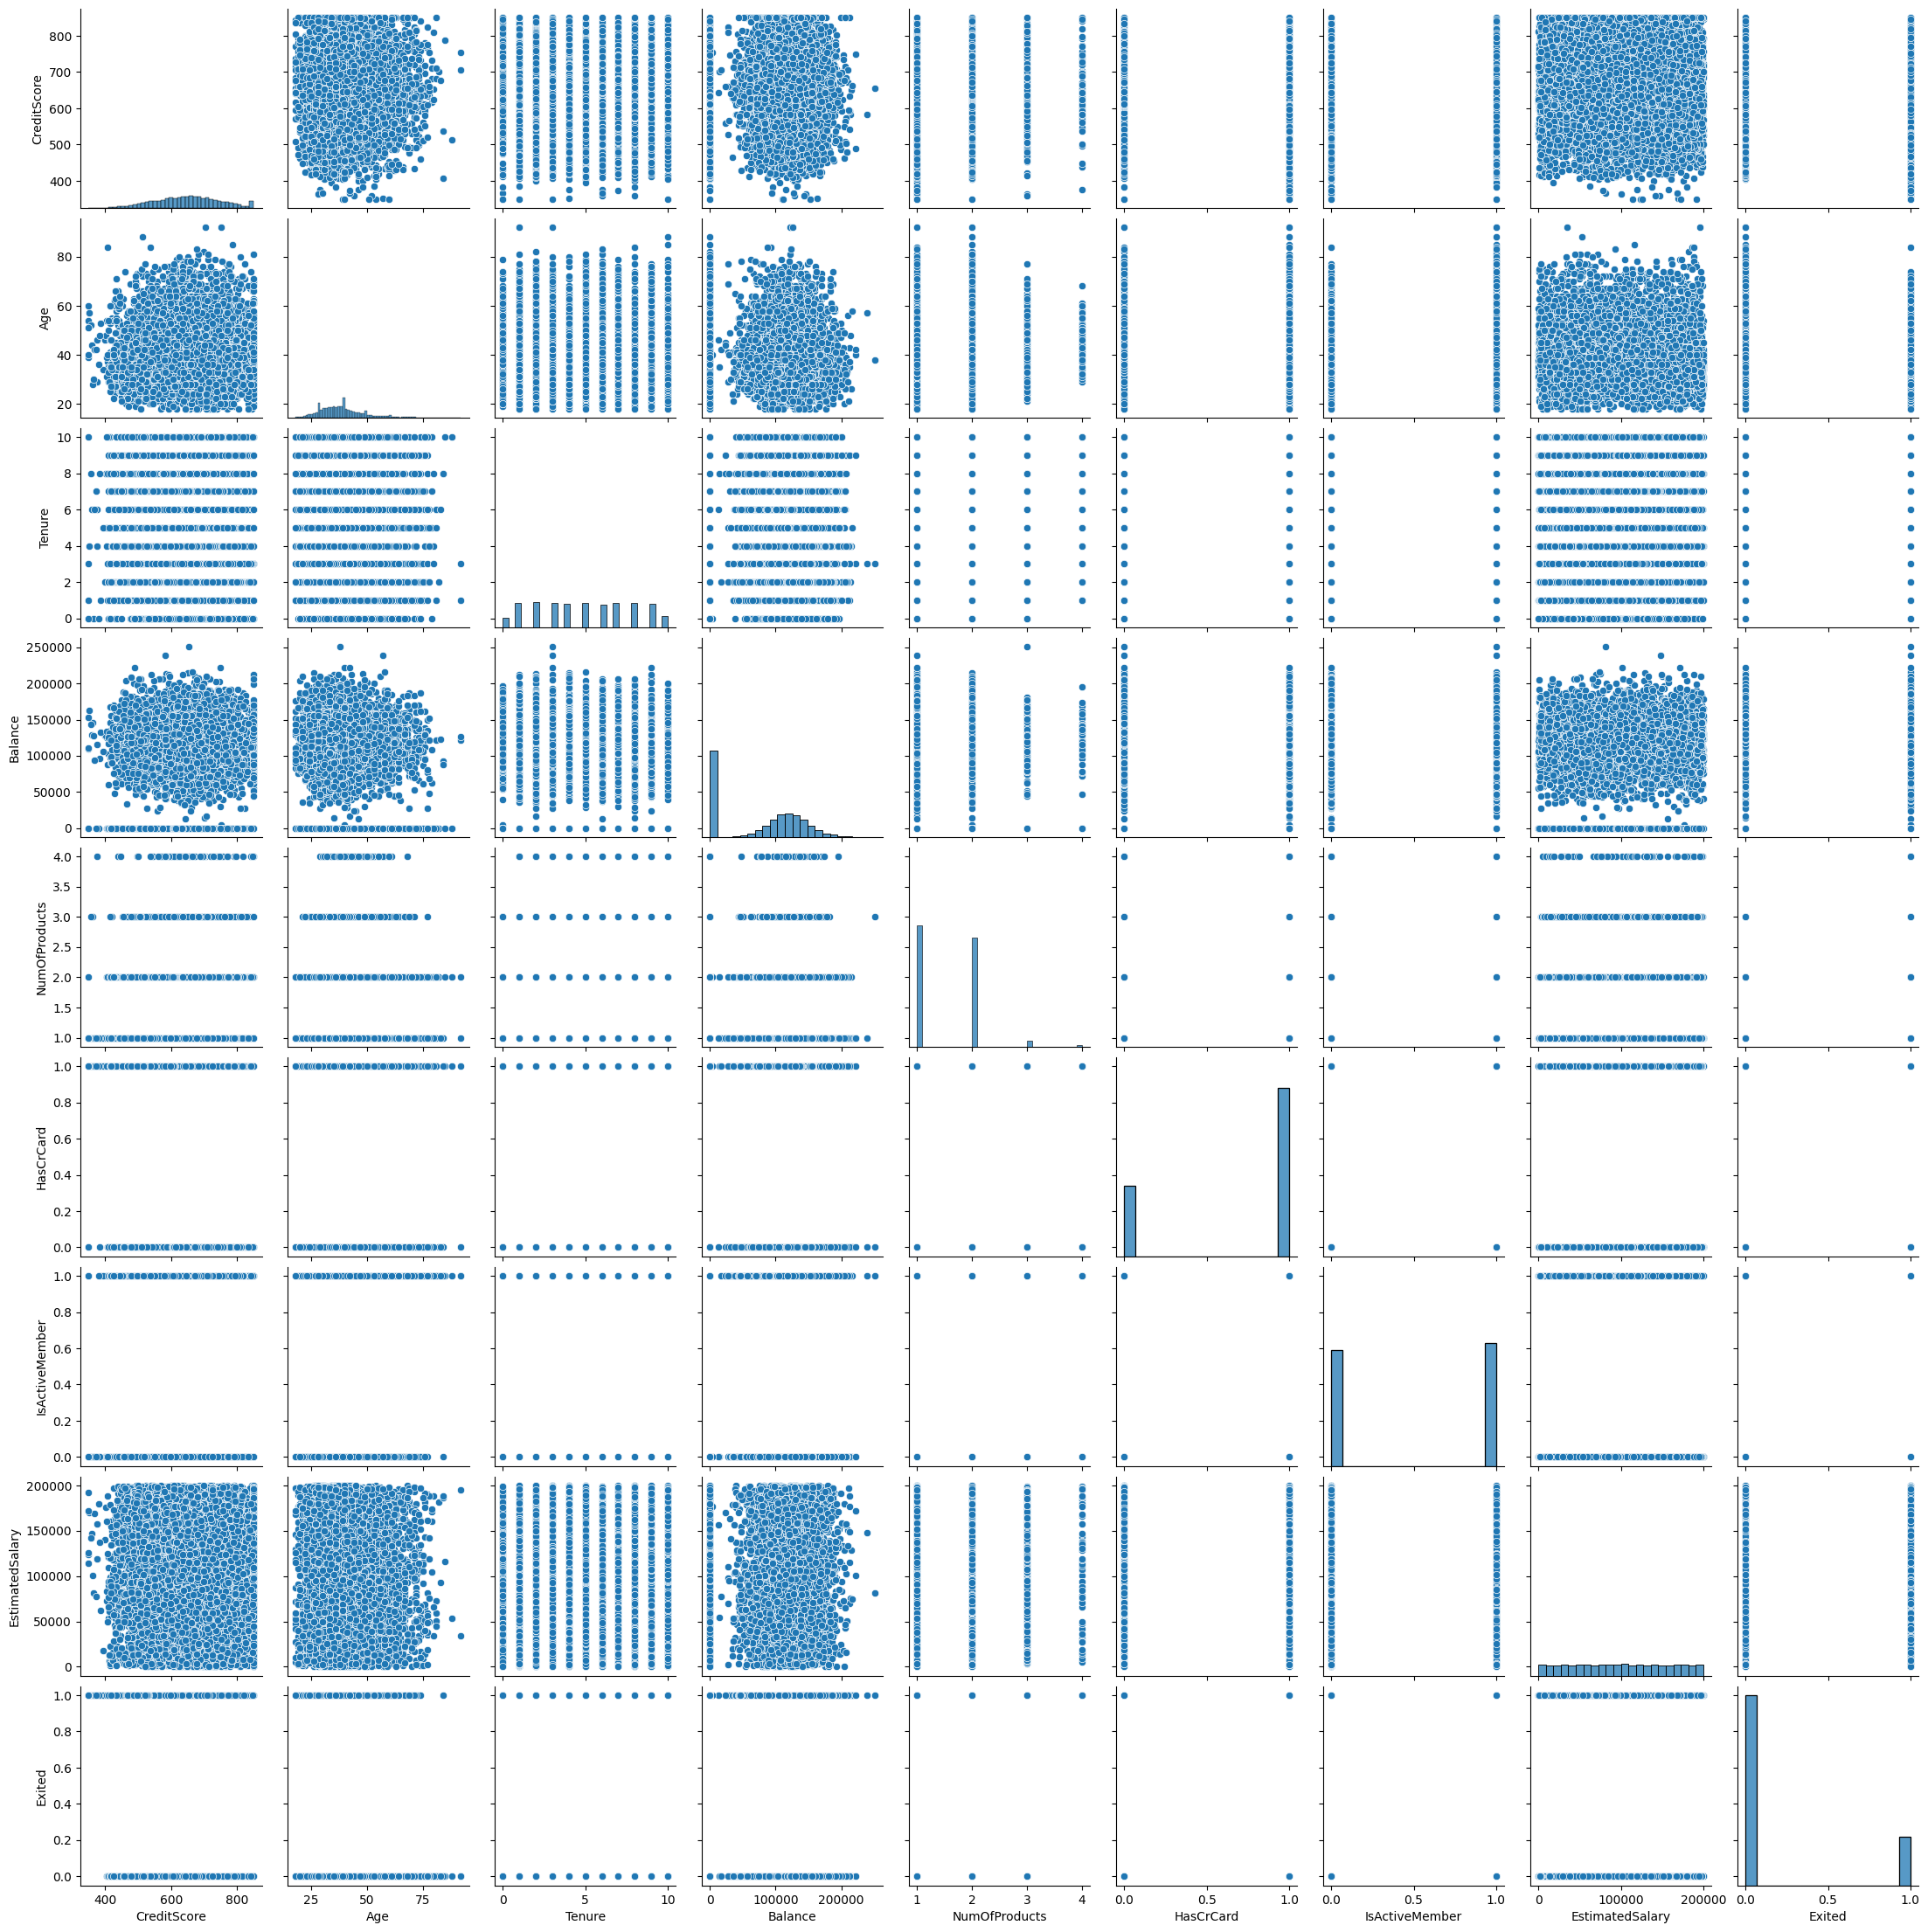

In [9]:
# Pairplot untuk fitur numerik
sns.pairplot(num_features)
plt.show()

C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\3924859044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=data, palette='viridis')


<Axes: xlabel='Exited', ylabel='count'>

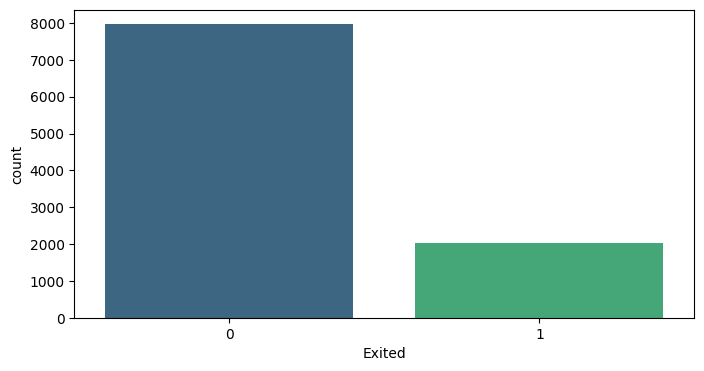

In [10]:
# Visualisasi distribusi variabel target
plt.figure(figsize=(8,4))
sns.countplot(x='Exited', data=data, palette='viridis')

### Churn Rate Analysis

C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\2123857421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_geo, x='Geography', y='Exited', palette='viridis', ax=axes[0])
C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\2123857421.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_gen, x='Gender', y='Exited', palette='viridis', ax=axes[1])
C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\2123857421.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_active, x='IsActiveMember', y='Exited', palette='v

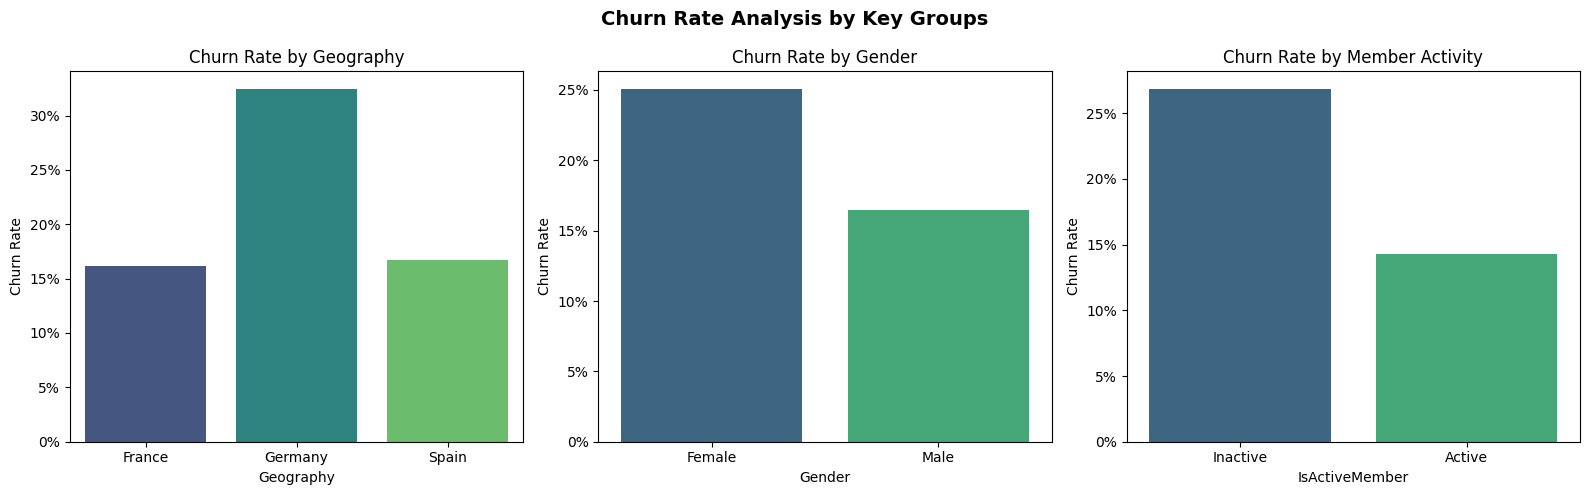

C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\2123857421.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_age, x='AgeGroup', y='Exited', palette='viridis')


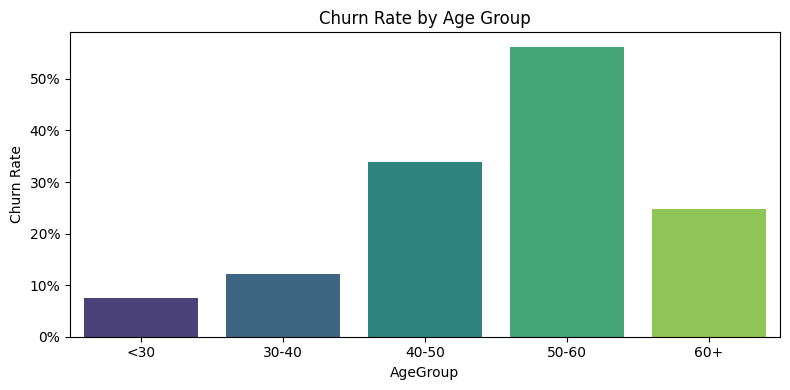

In [11]:
# Churn rate per grup
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Geography
churn_geo = data_raw.groupby('Geography')['Exited'].mean().reset_index()
sns.barplot(data=churn_geo, x='Geography', y='Exited', palette='viridis', ax=axes[0])
axes[0].set_title('Churn Rate by Geography')
axes[0].set_ylabel('Churn Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Gender
churn_gen = data_raw.groupby('Gender')['Exited'].mean().reset_index()
sns.barplot(data=churn_gen, x='Gender', y='Exited', palette='viridis', ax=axes[1])
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Active Member
churn_active = data_raw.groupby('IsActiveMember')['Exited'].mean().reset_index()
churn_active['IsActiveMember'] = churn_active['IsActiveMember'].map({0: 'Inactive', 1: 'Active'})
sns.barplot(data=churn_active, x='IsActiveMember', y='Exited', palette='viridis', ax=axes[2])
axes[2].set_title('Churn Rate by Member Activity')
axes[2].set_ylabel('Churn Rate')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Churn Rate Analysis by Key Groups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Age group
data_raw['AgeGroup'] = pd.cut(data_raw['Age'], bins=[0,30,40,50,60,100],
                               labels=['<30','30-40','40-50','50-60','60+'])
churn_age = data_raw.groupby('AgeGroup', observed=True)['Exited'].mean().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=churn_age, x='AgeGroup', y='Exited', palette='viridis')
plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


# **Encoding**

In [12]:
from sklearn.preprocessing import LabelEncoder

# Gender: binary (2 kategori) -> LabelEncoder aman
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# Geography: nominal (3 kategori) -> OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
geo_encoded = ohe.fit_transform(data[['Geography']])
geo_cols = ohe.get_feature_names_out(['Geography'])
geo_df = pd.DataFrame(geo_encoded, columns=geo_cols, index=data.index)

data = data.drop(columns=['Geography'])
data = pd.concat([data, geo_df], axis=1)

print('Kolom setelah encoding:', data.columns.tolist())
data.head()


Kolom setelah encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


# **Data Splitting**

In [13]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()

# Pisahkan fitur (x) dan target (y)
x = data.drop(columns=['Exited'])
y = data['Exited']

# Split data menjadi set pelatihan dan set uji
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Normalisasi semua kolom numerik
numeric_columns = x_train.select_dtypes(include=['int64', 'float64']).columns
x_train[numeric_columns] = scaler.fit_transform(x_train[numeric_columns])
x_test[numeric_columns] = scaler.transform(x_test[numeric_columns])

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: x_train={x_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: x_test={x_test.shape}, y_test={y_test.shape}")

Training set shape: x_train=(8000, 11), y_train=(8000,)
Test set shape: x_test=(2000, 11), y_test=(2000,)


# **Model Training**

In [14]:
# Pelatihan semua model
knn = KNeighborsClassifier().fit(x_train, y_train)
dt  = DecisionTreeClassifier(random_state=42).fit(x_train, y_train)
rf  = RandomForestClassifier(n_estimators=100, random_state=42).fit(x_train, y_train)
svm = SVC(probability=True, random_state=42).fit(x_train, y_train)
nb  = GaussianNB().fit(x_train, y_train)

print('Model training selesai.')


Model training selesai.


# **Model Evaluation**

In [15]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Confusion Matrix': cm,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_prob'   : y_prob,
    }

models = {
    'K-Nearest Neighbors': knn,
    'Decision Tree'      : dt,
    'Random Forest'      : rf,
    'SVM'                : svm,
    'Naive Bayes'        : nb,
}

results = {name: evaluate_model(m, x_test, y_test) for name, m in models.items()}

summary_df = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : f"{r['Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall'   : f"{r['Recall']:.4f}",
        'F1-Score' : f"{r['F1-Score']:.4f}",
        'ROC-AUC'  : f"{r['ROC-AUC']:.4f}",
    }
    for name, r in results.items()
])
print(summary_df.to_string(index=False))


              Model Accuracy Precision Recall F1-Score ROC-AUC
K-Nearest Neighbors   0.8235    0.5935 0.3232   0.4185  0.7359
      Decision Tree   0.7870    0.4617 0.5064   0.4830  0.6810
      Random Forest   0.8655    0.7627 0.4580   0.5723  0.8575
                SVM   0.8510    0.8467 0.2952   0.4377  0.8096
        Naive Bayes   0.8335    0.6351 0.3588   0.4585  0.8044


## Confusion Matrix

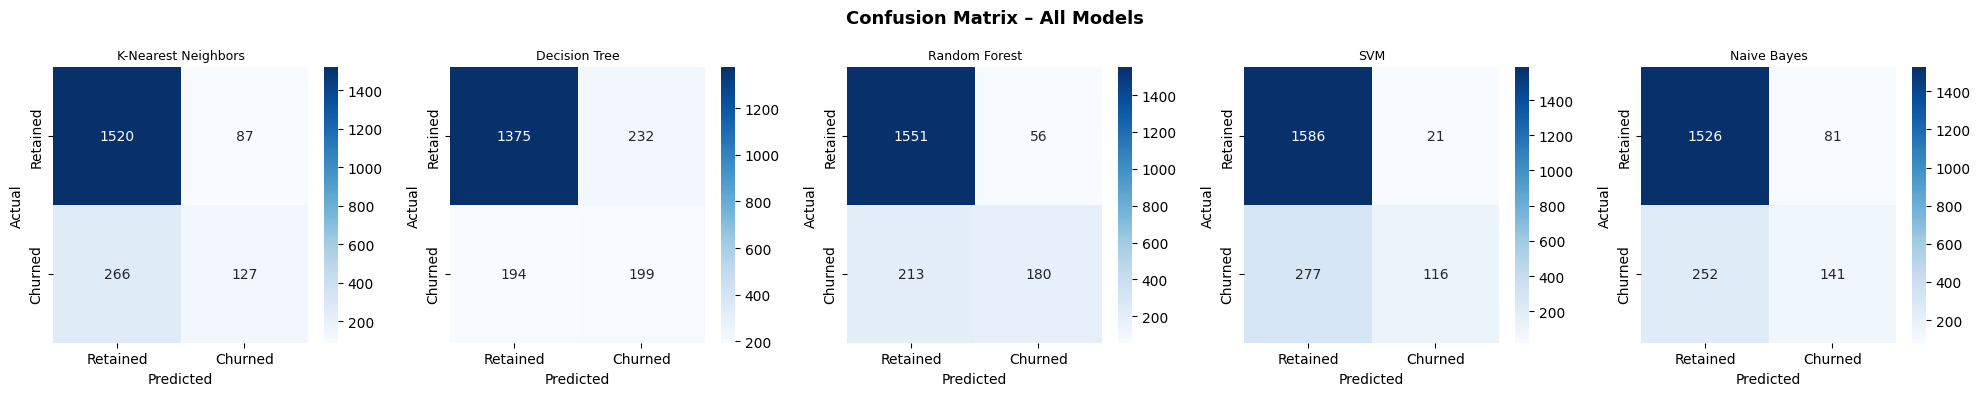

In [16]:
# Visualisasi Confusion Matrix untuk semua model
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r['Confusion Matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'], ax=ax)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## ROC-AUC Curve

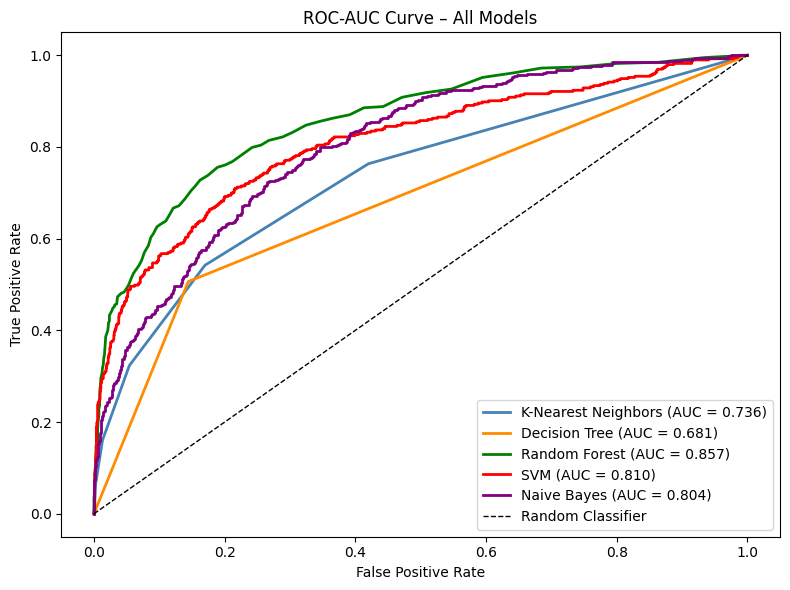

In [17]:
# ROC-AUC Curve untuk semua model
plt.figure(figsize=(8, 6))
colors = ['steelblue','darkorange','green','red','purple']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {r['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve – All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Feature Importance

C:\Users\akbar\AppData\Local\Temp\ipykernel_15628\1088004465.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


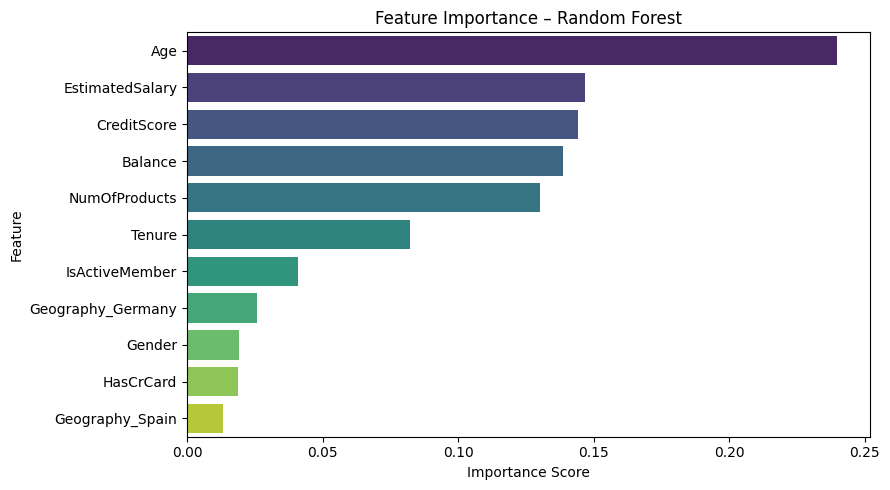

          Feature  Importance
              Age    0.239783
  EstimatedSalary    0.146638
      CreditScore    0.144214
          Balance    0.138613
    NumOfProducts    0.130255
           Tenure    0.082427
   IsActiveMember    0.041110
Geography_Germany    0.025711
           Gender    0.019258
        HasCrCard    0.018722
  Geography_Spain    0.013268


In [18]:
# Feature Importance – Random Forest
feature_names = x_train.columns.tolist()
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance – Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))


# **Conclusion**

## Model Performance Summary
Random Forest achieved the best overall performance with **86.55% accuracy** and **ROC-AUC of 0.857**, making it the most suitable model for identifying potential churners in this dataset.

## Why Recall Is Low Across All Models
The dataset is **class-imbalanced**: approximately 80% of customers did not churn, while only ~20% did. Models trained on imbalanced data tend to be biased toward the majority class, which inflates accuracy but suppresses Recall. For example, a model that always predicts "not churned" would achieve ~80% accuracy while detecting zero actual churners.

This explains why SVM achieves high Precision (0.847) but very low Recall (0.295) -- it only predicts churn when very confident, missing most actual churn cases.

**For production use**, this should be addressed with:
- `class_weight='balanced'` on tree-based models
- Oversampling techniques such as SMOTE
- Optimizing threshold on predicted probabilities toward maximizing F1 or Recall

## Key Drivers of Churn (from Feature Importance)
1. **Age** -- customers aged 40-60 churn significantly more
2. **NumOfProducts** -- customers with 3-4 products have a surprisingly high churn rate
3. **IsActiveMember** -- inactive members are ~2x more likely to churn
4. **Balance** -- high balance combined with inactivity is a strong churn signal
5. **Geography_Germany** -- German customers have the highest churn rate (~32%)

## Business Recommendations
- Prioritize retention efforts on customers aged 40-60, especially in Germany
- Implement re-engagement programs for inactive members before they churn
- Review product bundling strategy -- more products does not correlate with loyalty
- Deploy Random Forest as an early-warning churn scoring system
